In [2]:
import sys
import warnings
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib as mpl

warnings.filterwarnings('ignore', category=FutureWarning)

import pylimma


In [4]:
df = pd.read_csv("/Users/kaylaxu/Desktop/dp3_project/data/processed/PROT/normalized_full_results/PROT_placenta.csv")
uncorrected = pd.read_csv("/Users/kaylaxu/Desktop/dp3_project/data/raw/extracted/PROT/plasma/uncorrected_plasma_expr.csv")
targets = df[['SampleID',   'Group', 'Subgroup', 'GestAgeDelivery']]
targets.index = targets["SampleID"]
targets_uncorrected = uncorrected[['SampleID',"SubjectID", "SampleGestAge",'Batch', 'Group', 'Subgroup', 'GestAgeDelivery']]
targets_uncorrected.index = targets_uncorrected["SampleID"]
proteome = df.drop(targets.columns, axis=1)
proteome_uncorrected = uncorrected.drop(['SampleID' ,"SubjectID", "SampleGestAge",'Batch', 'Group', 'Subgroup', 'GestAgeDelivery'], axis=1)
df

,SampleID,Batch,Group,Subgroup,GestAgeDelivery,A1BG,AAMDC,AARSD1,ABCA2,ABHD14B,...,ZCCHC8,ZFYVE19,ZHX2,ZNF75D,ZNF830,ZNRD2,ZNRF4,ZP3,ZP4,ZPR1
0,DP3-0005,1.0,FGR,FGR <5,36.857143,2.126500,3.745500,7.747500,2.634200,5.266700,...,7.262500,9.738900,7.695300,1.328600,6.261700,7.573700,1.996800,-2.940300,-0.806700,0.075400
1,DP3-0006,1.0,Control,Control,40.000000,2.151400,2.727900,7.528500,1.704800,5.010000,...,7.784100,9.013400,7.462300,1.661000,6.008600,7.629200,1.820200,-2.366700,-0.193000,0.140500
2,DP3-0008,2.0,Control,Control,39.000000,2.254739,2.504130,7.599012,2.129147,5.640454,...,6.554329,9.136889,7.271226,0.252121,5.751730,7.808781,3.195562,-2.565647,-0.463317,-0.006013
3,DP3-0009,2.0,HDP,gHTN,37.000000,2.010540,3.147484,7.587148,1.863375,4.647191,...,6.890732,9.563545,7.143570,0.371727,5.714611,7.078488,3.011142,-3.266526,-1.223066,-0.140439
4,DP3-0018,1.0,Control,Control,38.285714,2.050700,3.484800,7.554500,2.219600,5.300500,...,7.010500,8.358500,7.053400,0.671400,5.763700,6.682100,3.315300,-2.938000,0.481300,0.245500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,DP3-0409,3.0,HDP,EO severe PE,33.571429,2.558005,2.991184,7.579650,1.692134,5.008591,...,7.334525,9.527966,7.495604,1.106013,6.054039,7.581743,3.063824,-2.674209,-0.324282,0.562064
110,DP3-0416,3.0,Control,Control,37.571429,1.969331,2.363203,7.551190,1.429482,5.074963,...,7.168900,9.260458,7.094840,0.381197,5.825143,7.162160,2.248090,-2.959508,-0.792805,-0.641768
111,DP3-0419,3.0,HDP,LO severe SIPE,36.285714,1.803036,3.351662,7.551247,2.078108,5.264482,...,7.649356,9.130885,7.140533,0.092636,5.943901,7.522717,2.218222,-1.691089,-1.143986,0.015097
112,DP3-0420,3.0,FGR,FGR <3,40.000000,2.462282,3.312302,7.589136,1.354656,5.177481,...,7.161348,9.041161,7.155873,0.227355,5.736895,7.310215,2.842136,-2.694244,-1.408428,0.375724


AnnData shape: (530, 2815)  (samples x proteins)

group counts:
group
3    248
2    154
1    128
Name: count, dtype: int64


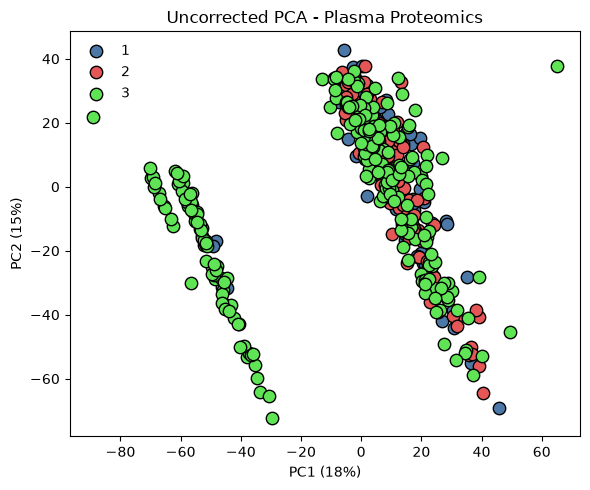

In [35]:
X = proteome_uncorrected
var_df = pd.DataFrame(X.columns)
var_df.columns = ["uniprot_id"]
var_df.index = var_df["uniprot_id"]

obs_df = targets_uncorrected
obs_df['group'] = pd.Categorical(obs_df["Batch"], 
                                 categories = [1, 2, 3],
                                 ordered = False)

adata = ad.AnnData(X=X, obs=obs_df, var=var_df)
adata.obs_names = obs_df.index
adata.var_names = var_df.index

print(f'AnnData shape: {adata.shape}  (samples x proteins)')
print(f'\ngroup counts:\n{adata.obs.group.value_counts()}')
adata.var.head()

fig, ax = plt.subplots(figsize=(6, 5))

# PCA on samples (centre proteins, drop any all-NaN rows just in case).
Xc = adata.X - adata.X.mean(axis=0, keepdims=True)
U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
pcs = U * s
var_explained = (s ** 2) / (s ** 2).sum()

group_palette = {1: '#4c78a8', 2: '#e45756', 3: "#5fe456"}
for grp, colour in group_palette.items():
    m = (adata.obs['Batch'] == grp).values
    ax.scatter(pcs[m, 0], pcs[m, 1], s=80,
                color=colour, edgecolor='black', label=grp)
ax.set_xlabel(f'PC1 ({var_explained[0]:.0%})')
ax.set_ylabel(f'PC2 ({var_explained[1]:.0%})')
ax.set_title('Uncorrected PCA - Plasma Proteomics')
ax.legend(frameon=False)

fig.tight_layout()
plt.savefig("/Users/kaylaxu/Desktop/dp3_project/04_results_and_figures/batch_correction/PROT/uncorrected_PCA_plasma.jpeg")

In [44]:
proteome.index = targets.index

In [45]:
proteome

,A1BG,AAMDC,AARSD1,ABCA2,ABHD14B,ABL1,ABO,ABRAXAS2,ACAA1,ACADM,...,ZFYVE19,ZHX2,ZNF75D,ZNF830,ZNRD2,ZNRF4,ZP3,ZP4,ZPR1,Timepoint
SampleID,,,,,,,,,,,,,,,,,,,,,
DP3-0005A,-0.118800,0.010800,-0.969100,0.612200,-0.323100,-0.438300,0.997500,-1.085200,-3.607000,-0.961800,...,-1.135300,-0.066700,-1.900600,0.182300,-1.309200,-0.341700,-4.710900,-0.394100,1.984200,1
DP3-0006A,-0.845500,-0.282800,-0.073500,-1.159700,-0.101100,-0.526900,1.064900,-0.918800,-0.279100,-0.094600,...,-0.026200,-0.146300,5.360100,0.217900,-0.029200,-0.286200,-3.291600,0.031400,-1.265700,1
DP3-0008A,-0.631778,0.211358,-0.231405,0.417571,0.144815,-0.461434,1.909665,-0.711896,-0.736252,1.393388,...,0.254662,0.098875,0.560809,0.948914,0.276204,0.363901,-0.480698,0.046412,-0.392106,1
DP3-0009A,-0.535090,-0.171861,-0.504571,-0.443781,-0.361365,-0.541192,-4.088634,-0.142338,0.574601,1.171401,...,-0.268706,-0.185017,-0.345935,-0.109435,0.796898,0.286556,0.503058,-1.742688,-0.896260,1
DP3-0018A,0.173100,0.318900,0.779700,0.654800,1.088900,0.801800,-6.588900,0.330100,1.527200,0.222400,...,1.537600,0.209900,-9.368100,0.406300,0.054500,0.456100,1.065400,-0.387300,0.724000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DP3-0409A,0.485792,-0.193567,0.351991,0.256900,-0.565429,-0.488069,0.312260,0.070543,-2.000750,-1.221296,...,-0.124129,0.015646,1.980986,-0.036443,0.158230,-0.636976,-0.076580,-0.573538,0.200267,1
DP3-0416A,-0.469178,-0.907137,-0.438155,-0.147727,-0.596229,-0.786530,0.304262,-0.689786,-1.038877,0.590027,...,-1.348046,-0.094544,-0.159794,0.136417,-1.964808,-0.012489,-0.227694,-0.066379,0.599082,1
DP3-0419A,-0.065072,-0.332589,-0.251848,-0.070321,-0.226809,-0.436704,1.355563,-0.842189,-1.440468,-2.590558,...,-0.898216,-0.158753,-0.256768,0.559146,0.034403,-0.426773,-0.645576,-2.350403,1.856473,1


In [5]:
by = "Batch"
X = proteome
var_df = pd.DataFrame(X.columns)
var_df.columns = ["uniprot_id"]
var_df.index = var_df["uniprot_id"]


obs_df = targets
#unique_subgroups = obs_df[by].unique()


adata = ad.AnnData(X=X, obs=obs_df, var=var_df)
adata.obs_names = obs_df.index
adata.var_names = var_df.index
'''
print(f'AnnData shape: {adata.shape}  (samples x proteins)')
#print(f'\ngroup counts:\n{adata.obs.group.value_counts()}')
adata.var.head()

fig, ax = plt.subplots(figsize=(6, 5))

# PCA on samples (centre proteins, drop any all-NaN rows just in case).
Xc = adata.X - adata.X.mean(axis=0, keepdims=True)
U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
pcs = U * s
var_explained = (s ** 2) / (s ** 2).sum()

# --- Dynamically generate the group palette ---
num_groups = len(unique_subgroups)
# 'tab20' provides 20 distinct categorical colors. If you have more than 20 subgroups, 
# it falls back to spacing them out along the 'rainbow' continuous colormap.
if num_groups <= 20:
    cmap = plt.get_cmap('tab20')
    colors = [cmap(i) for i in range(num_groups)]
else:
    cmap = plt.get_cmap('rainbow')
    colors = cmap(np.linspace(0, 1, num_groups))

group_palette = dict(zip(unique_subgroups, colors))
# ----------------------------------------------

for grp, colour in group_palette.items():
    m = (adata.obs[by] == grp).values
    ax.scatter(pcs[m, 0], pcs[m, 1], s=80,
                color=colour, edgecolor='black', label=grp)

ax.set_xlabel(f'PC1 ({var_explained[0]:.0%})')
ax.set_ylabel(f'PC2 ({var_explained[1]:.0%})')
ax.set_title('Batch Corrected PCA - Plasma Proteomics')

# Move legend outside the plot area in case there are many groups
ax.legend(frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')

fig.tight_layout()
plt.savefig("/Users/kaylaxu/Desktop/dp3_project/04_results_and_figures/batch_correction/PROT/corrected_PCA_plasma.jpeg")
'''

'\nprint(f\'AnnData shape: {adata.shape}  (samples x proteins)\')\n#print(f\'\ngroup counts:\n{adata.obs.group.value_counts()}\')\nadata.var.head()\n\nfig, ax = plt.subplots(figsize=(6, 5))\n\n# PCA on samples (centre proteins, drop any all-NaN rows just in case).\nXc = adata.X - adata.X.mean(axis=0, keepdims=True)\nU, s, Vt = np.linalg.svd(Xc, full_matrices=False)\npcs = U * s\nvar_explained = (s ** 2) / (s ** 2).sum()\n\n# --- Dynamically generate the group palette ---\nnum_groups = len(unique_subgroups)\n# \'tab20\' provides 20 distinct categorical colors. If you have more than 20 subgroups, \n# it falls back to spacing them out along the \'rainbow\' continuous colormap.\nif num_groups <= 20:\n    cmap = plt.get_cmap(\'tab20\')\n    colors = [cmap(i) for i in range(num_groups)]\nelse:\n    cmap = plt.get_cmap(\'rainbow\')\n    colors = cmap(np.linspace(0, 1, num_groups))\n\ngroup_palette = dict(zip(unique_subgroups, colors))\n# ----------------------------------------------\n\nfor g

In [38]:
from sklearn.cluster import KMeans

# 1. Cluster the samples based on their first 2 Principal Components
# We use n_clusters=2 since you observed two distinct clusters
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(pcs[:, :2]) # pcs[:, 0] is PC1, pcs[:, 1] is PC2

# 2. Add the cluster labels to your observation dataframe
adata.obs['pca_cluster'] = cluster_labels
obs_df['pca_cluster'] = cluster_labels

# 3. Extract the metadata (rows) for each cluster
cluster_0_metadata = obs_df[obs_df['pca_cluster'] == 0]
cluster_1_metadata = obs_df[obs_df['pca_cluster'] == 1]

# 4. Extract the proteome expression data (rows) for each cluster
cluster_0_proteome = proteome.loc[cluster_0_metadata.index]
cluster_1_proteome = proteome.loc[cluster_1_metadata.index]

print(f"Cluster 0 size: {len(cluster_0_metadata)} samples")
print(f"Cluster 1 size: {len(cluster_1_metadata)} samples")

# Optional: Print the subgroup breakdown of each cluster to see what's driving the split
print("\nCluster 0 Subgroup makeup:")
print(cluster_0_metadata['Subgroup'].value_counts())

print("\nCluster 1 Subgroup makeup:")
print(cluster_1_metadata['Subgroup'].value_counts())

Cluster 0 size: 87 samples
Cluster 1 size: 443 samples

Cluster 0 Subgroup makeup:
Subgroup
Control                     38
sPTB                        11
FGR <5                       6
LO severe PE                 6
LO mild PE                   6
FGR <5+cHTN                  5
LO FGR <5                    3
FGR <3                       3
LO FGR <3                    3
EO severe SIPE               3
EO FGR <5 + EO severe PE     2
pp HELLP                     1
Name: count, dtype: int64

Cluster 1 Subgroup makeup:
Subgroup
Control                     197
LO mild PE                   32
LO severe PE                 28
sPTB                         26
FGR <5                       23
FGR <3                       22
LO severe SIPE               19
gHTN                         18
EO severe PE                 14
LO FGR <5                     9
FGR <3+cHTN                   9
LO mild SIPE                  9
sptb                          8
pp gHTN                       4
FGR <3 + LO severe PE    

In [661]:
cluster_0_metadata.to_csv("/Users/kaylaxu/Desktop/dp3_project/data/processed/PROT/cluster0_meta.csv")
cluster_0_proteome.to_csv("/Users/kaylaxu/Desktop/dp3_project/data/processed/PROT/cluster0_expr.csv")
cluster_1_metadata.to_csv("/Users/kaylaxu/Desktop/dp3_project/data/processed/PROT/cluster1_meta.csv")
cluster_1_proteome.to_csv("/Users/kaylaxu/Desktop/dp3_project/data/processed/PROT/cluster1_expr.csv")

design matrix:
           Intercept  HDP
SampleID                 
DP3-0005         1.0  0.0
DP3-0006         1.0  0.0
DP3-0008         1.0  0.0
DP3-0009         1.0  1.0
DP3-0018         1.0  0.0
DP3-0024         1.0  0.0
DP3-0025         1.0  1.0
DP3-0027         1.0  0.0
DP3-0028         1.0  0.0
DP3-0029E        1.0  0.0

contrast:
           CompvsCtrl
Intercept         0.0
HDP               1.0
keys stored in adata.uns["pylimma"]:
['Amean', 'F', 'F_p_value', 'coef_names', 'coefficients', 'contrast_names', 'contrasts', 'cov_coefficients', 'design', 'df_prior', 'df_residual', 'df_total', 'genes', 'lods', 'method', 'p_value', 'pivot', 'proportion', 'rank', 's2_post', 's2_prior', 'sigma', 'stdev_unscaled', 't', 'targets', 'var_prior']
differentially abundant proteins at adj_p_value < 0.05: 0
differentially abundant proteins at adj_p_value < 0.01: 0
design matrix:
           Intercept  FGR
SampleID                 
DP3-0005         1.0  1.0
DP3-0006         1.0  0.0
DP3-0008         1

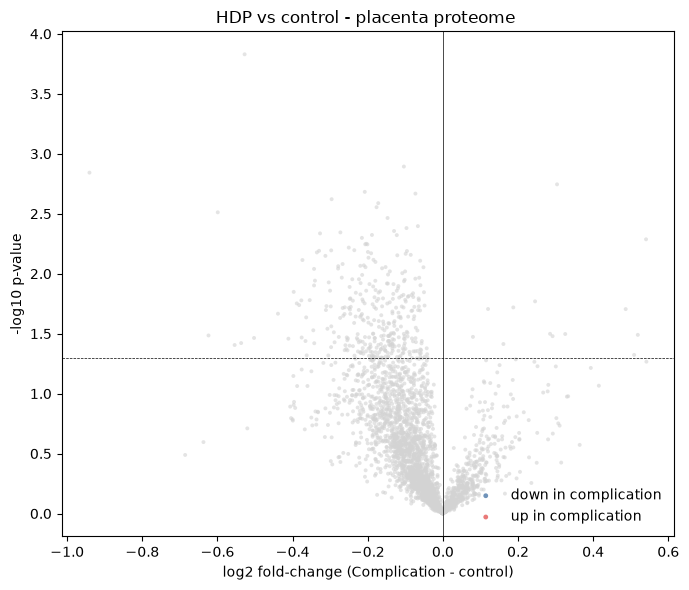

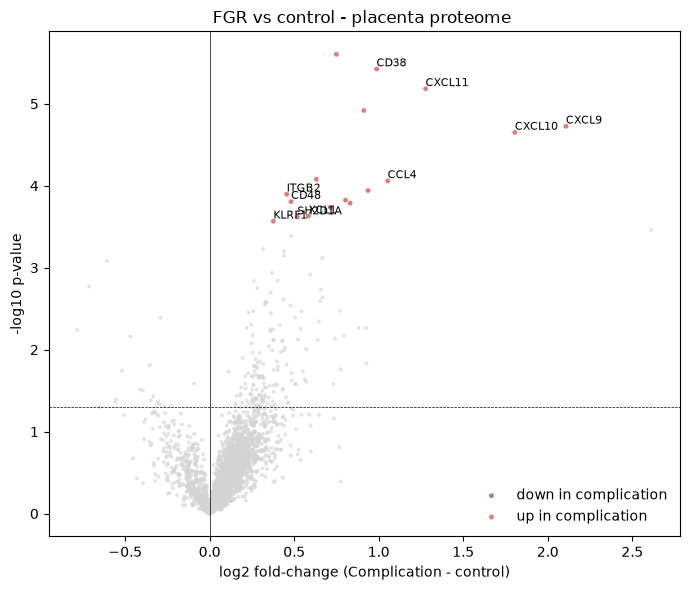

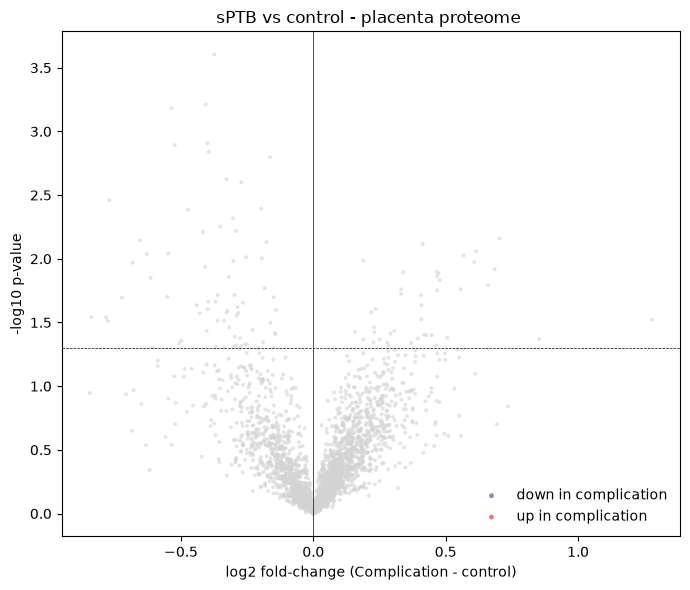

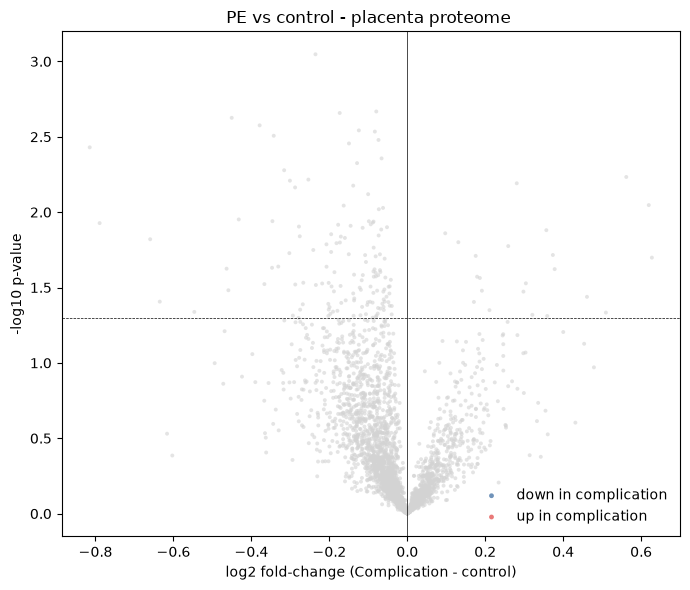

In [7]:
comps= ["HDP", "FGR", "sPTB", "PE"]
tissue = "placenta"

for complication in comps:
    if complication == "PE":
        group = adata.obs["Subgroup"]
        design = pd.DataFrame({
            'Intercept':     1.0,
            complication: group.str.contains("PE|HELLP", regex=True, na=False).astype(float).values,
            }, index=adata.obs_names)
    else:
        group  = adata.obs['Group']
        design = pd.DataFrame({
            'Intercept':     1.0,
            complication: (group == complication).astype(float).values,
            }, index=adata.obs_names)


    
    contrasts = pylimma.make_contrasts(CompvsCtrl=complication, levels=design)

    print('design matrix:')
    print(design.head(10))
    print('\ncontrast:')
    print(contrasts)

    pylimma.lm_fit(adata, design)
    pylimma.contrasts_fit(adata, contrasts=contrasts)
    pylimma.e_bayes(adata)

    print('keys stored in adata.uns["pylimma"]:')
    print(sorted(adata.uns['pylimma'].keys()))

    top = pylimma.top_table(adata, coef='CompvsCtrl',
                            number=np.inf, sort_by='p')


    top = top.join(adata.var[['uniprot_id']], how='left')

    n_sig_05 = int((top['adj_p_value'] < 0.05).sum())
    n_sig_01 = int((top['adj_p_value'] < 0.01).sum())
    print(f'differentially abundant proteins at adj_p_value < 0.05: {n_sig_05:,}')
    print(f'differentially abundant proteins at adj_p_value < 0.01: {n_sig_01:,}')

    display_cols = ['uniprot_id', 'log_fc', 'ave_expr', 't',
                    'p_value', 'adj_p_value', 'b']
    top.loc[:, display_cols].head(15).round(3)

    fig, ax = plt.subplots(figsize=(7, 6))

    sig_up   = (top['adj_p_value'] < 0.05) & (top['log_fc'] > 0)
    sig_down = (top['adj_p_value'] < 0.05) & (top['log_fc'] < 0)
    ns       = ~(sig_up | sig_down)

    nlp = -np.log10(np.maximum(top['p_value'].values, 1e-300))

    ax.scatter(top.loc[ns, 'log_fc'],   nlp[ns.values],
            s=8, color='lightgrey', alpha=0.6, edgecolor='none')
    ax.scatter(top.loc[sig_down, 'log_fc'], nlp[sig_down.values],
            s=12, color='#4c78a8', alpha=0.8,
            edgecolor='none', label= 'down in complication')
    ax.scatter(top.loc[sig_up, 'log_fc'],   nlp[sig_up.values],
            s=12, color='#e45756', alpha=0.8,
            edgecolor='none', label='up in complication')


    sig = top[top['adj_p_value'] < 0.05].copy()
    top_up   = sig.sort_values('log_fc', ascending=False).head(5)
    top_down = sig.sort_values('log_fc', ascending=True ).head(5)
    for _, row in pd.concat([top_up, top_down]).iterrows():
        label = row['uniprot_id']
        if not isinstance(label, str) or ';' in label or label == '':
            continue
        ax.annotate(label, (row['log_fc'], -np.log10(max(row['p_value'], 1e-300))),
                    fontsize=8, ha='left', va='bottom')

    ax.axhline(-np.log10(0.05), color='black', lw=0.5, linestyle='--')
    ax.axvline(0, color='black', lw=0.5)
    ax.set_xlabel('log2 fold-change (Complication - control)')
    ax.set_ylabel('-log10 p-value')
    ax.set_title(f'{complication} vs control - placenta proteome ')
    ax.legend(frameon=False, loc='lower right')
    fig.tight_layout()
    plt.savefig(f"/Users/kaylaxu/Desktop/dp3_project/04_results_and_figures/differential_expression/limma_plots/PROT_{complication}_v_control_{tissue}.jpeg")

In [655]:
targets.groupby(["Batch"])["Group"].value_counts()

Batch  Group  
1      Control    64
       HDP        39
       sPTB       14
       FGR        11
2      Control    80
       HDP        43
       FGR        24
       sPTB        7
3      Control    91
       HDP        79
       FGR        52
       sPTB       26
Name: count, dtype: int64

In [656]:
targets

,SampleID,SubjectID,SampleGestAge,Batch,Group,Subgroup,GestAgeDelivery,pca_cluster
SubjectID,,,,,,,,
DP3-0005,DP3-0005 A,DP3-0005,11.857143,1,FGR,FGR <5,36.857143,1
DP3-0005,DP3-0005 B,DP3-0005,19.571429,1,FGR,FGR <5,36.857143,1
DP3-0005,DP3-0005 C,DP3-0005,28.857143,1,FGR,FGR <5,36.857143,1
DP3-0005,DP3-0005 D,DP3-0005,36.714286,1,FGR,FGR <5,36.857143,1
DP3-0006,DP3-0006 A,DP3-0006,7.428571,1,Control,Control,40.000000,1
...,...,...,...,...,...,...,...,...
DP3-0423,DP3-0423EC,DP3-0423,29.000000,3,HDP,LO mild SIPE,38.142857,1
DP3-0423,DP3-0423ED,DP3-0423,37.000000,3,HDP,LO mild SIPE,38.142857,1
DP3-0423,DP3-0423EE,DP3-0423,38.857143,3,HDP,LO mild SIPE,38.142857,1
